In [2]:
import h5py
import numpy as np
import pandas as pd
from astropy.io import fits
from tqdm import tqdm
import os
import healpy as hp
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.moc import uniq2nest, uniq2pixarea
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import torch

/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# gw_df = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv")
SIM_NAME = "LSST_KN_BNS_AUG"
SIM_PATH = f"/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/{SIM_NAME}/"
Neg_path = "/fred/oz016/bgao_kn/data/Tutorial_LSST_sims_2025/sims/"
output_path = f"/fred/oz016/bgao_kn/data/{SIM_NAME}/"
BAND_MAP = {                   # Mapping filters to channel indices
    'LSST-u': 0, 'LSST-g': 1, 'LSST-r': 2, 'LSST-i': 3, 'LSST-z': 4, 'LSST-Y': 5,
}
NEG_BAND_MAP = {               # Mapping filters to channel indices for negative samples
    'u': 0, 'g': 1, 'r': 2, 'i': 3, 'z': 4, 'Y': 5,
}
NUM_BANDS = 6
MAX_LC_LENGTH = 200  # Maximum length of light curves all band

In [4]:
gw_df = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns_aug/injections_final.csv")
# process gw data
valid_index = []

for gw_idx, row in tqdm(gw_df.iterrows(), total=len(gw_df)):
    event_id = int(row['simulation_id'])
    sim_dir = os.path.join(SIM_PATH, f"{SIM_NAME}_{event_id}")
    try:
        with fits.open(os.path.join(sim_dir, f"{SIM_NAME}_{event_id}_HEAD.FITS")) as hdul:
            head_data = hdul[1].data
            if len(head_data) == 0:
                continue
    except Exception as e:  # simulation failed, path do not exists
        continue
    valid_index.append(gw_idx)

print(f"Total valid GW+Optical samples: {len(valid_index)}")
valid_gw_df = gw_df.loc[valid_index]
valid_gw_df.reset_index(drop=True, inplace=True)
valid_gw_df.head()

  0%|          | 5/22941 [00:00<39:04,  9.78it/s]

100%|██████████| 22941/22941 [28:01<00:00, 13.64it/s]  

Total valid GW+Optical samples: 10152


,simulation_id,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,...,mej_dyn,mej_wind,mej_total,phi,costheta,distmean,diststd,redshift,mass1_detector,mass2_detector
0,0,61918.6860,1.527093e+09,1.775553,-0.755829,101.731670,-43.305802,0.679470,408.62390,1.586891,...,0.003499,0.014374,0.017873,63.489759,0.777906,338.827222,113.404008,0.086648,1.724391,1.674747
1,2,61417.4549,1.483787e+09,2.807560,-0.053046,160.861327,-3.039317,0.574456,384.82888,1.692769,...,0.004226,0.005875,0.010101,23.028581,0.839488,510.911771,154.289575,0.081867,1.831350,1.770628
2,11,64371.7342,1.739036e+09,2.746064,-0.086227,157.337855,-4.940458,2.765034,358.63833,1.619252,...,0.007638,0.063380,0.071019,52.927328,0.929936,369.137134,130.900267,0.076571,1.743240,1.212668
3,15,61409.8876,1.483133e+09,5.725129,-0.774004,328.025752,-44.347176,0.846417,185.59767,1.978727,...,0.000000,0.000000,0.007865,52.731087,0.662671,294.486526,99.517816,0.040640,2.059143,1.765380
4,18,63668.0848,1.678241e+09,1.809494,0.129121,103.676381,7.398088,0.269356,377.22800,1.363463,...,0.002344,0.017852,0.020196,34.835518,0.963942,392.507212,134.266124,0.080334,1.472995,1.326813


In [ ]:
valid_gw_df.to_csv("/fred/oz016/bgao_kn/data/LSST_KN_BNS_AUG/gw_catalog.csv", index=False)

In [5]:
valid_gw_df = pd.read_csv("/fred/oz016/bgao_kn/data/LSST_KN_BNS_AUG/gw_catalog.csv")
valid_gw_df

,simulation_id,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,...,mej_total,phi,costheta,distmean,diststd,redshift,mass1_detector,mass2_detector,NLIBID,NDET_LC
0,0,61918.6860,1.527093e+09,1.775553,-0.755829,101.731670,-43.305802,0.679470,408.62390,1.586891,...,0.017873,63.489759,0.777906,338.827222,113.404008,0.086648,1.724391,1.674747,12754.0,43.0
1,2,61417.4549,1.483787e+09,2.807560,-0.053046,160.861327,-3.039317,0.574456,384.82888,1.692769,...,0.010101,23.028581,0.839488,510.911771,154.289575,0.081867,1.831350,1.770628,9173.0,0.0
2,11,64371.7342,1.739036e+09,2.746064,-0.086227,157.337855,-4.940458,2.765034,358.63833,1.619252,...,0.071019,52.927328,0.929936,369.137134,130.900267,0.076571,1.743240,1.212668,7503.0,626.0
3,15,61409.8876,1.483133e+09,5.725129,-0.774004,328.025752,-44.347176,0.846417,185.59767,1.978727,...,0.007865,52.731087,0.662671,294.486526,99.517816,0.040640,2.059143,1.765380,13514.0,0.0
4,18,63668.0848,1.678241e+09,1.809494,0.129121,103.676381,7.398088,0.269356,377.22800,1.363463,...,0.020196,34.835518,0.963942,392.507212,134.266124,0.080334,1.472995,1.326813,4407.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10147,28120,61871.8617,1.523047e+09,4.568273,-1.197982,261.742757,-68.639295,0.358066,391.12695,1.625633,...,0.035246,33.274618,0.936576,338.759533,101.256131,0.083135,1.760780,1.262398,5600.0,5600.0
10148,28123,64475.9684,1.748042e+09,2.622926,-0.847280,150.282601,-48.545546,1.761310,250.60115,1.960303,...,0.007488,25.597288,0.189363,463.938378,134.930114,0.054339,2.066824,1.967797,14634.0,0.0
10149,28124,62494.6202,1.576854e+09,4.595259,0.359807,263.288958,20.615411,1.654493,204.68432,1.468854,...,0.068994,35.656082,0.083599,378.350154,104.330280,0.044689,1.534496,1.474906,6006.0,2726.0
10150,28130,61067.6761,1.453566e+09,1.514465,-0.844040,86.772447,-48.359953,0.870882,468.37635,1.324171,...,0.070531,64.047785,0.644152,569.098489,175.710456,0.098531,1.454643,1.404835,9338.0,0.0


In [20]:
# find max_lc_length
max_lc_length = 0
min_lc_length = 1e3
min_id = -1
max_id = -1
nobs = np.array([])
for gw_idx, row in tqdm(valid_gw_df.iterrows(), total=len(valid_gw_df)):
    event_id = int(row['simulation_id'])
    sim_dir = os.path.join(SIM_PATH, f"{SIM_NAME}_{event_id}")
    with fits.open(os.path.join(sim_dir, f"{SIM_NAME}_{event_id}_HEAD.FITS")) as hdul:
        head_data = hdul[1].data
        nobs = np.concatenate((nobs, head_data['NOBS']))
        if len(head_data) == 0:
            continue
        if min(head_data['NOBS']) < min_lc_length:
            min_lc_length = min(head_data['NOBS'])
            min_id = event_id
        if max(head_data['NOBS']) > max_lc_length:
            max_lc_length = max(head_data['NOBS'])
            max_id = event_id
print(f"Light curve length statistics over {len(nobs)} light curves:")
print(f"Max LC length across all bands: {max_lc_length} for event {max_id}")
print(f"Min LC length across all bands: {min_lc_length} for event {min_id}")

100%|██████████| 491/491 [00:20<00:00, 23.60it/s]

Light curve length statistics over 483659 light curves:
Max LC length across all bands: 216 for event 2222
Min LC length across all bands: 2 for event 105


Number of light curves with less than 5 observations: 6532


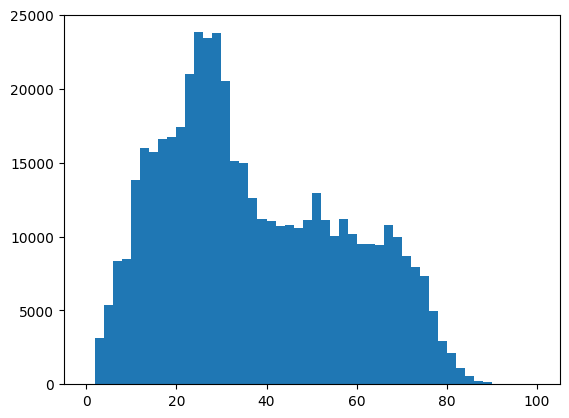

In [32]:
import matplotlib.pyplot as plt
plt.hist(nobs, bins=50, range=(0,100))
print("Number of light curves with less than 5 observations:", np.sum(nobs < 5))

In [16]:
# Functions for parsing SNANA FITS files, and sampling MOC skymaps
def parse_snana_fits(event_id, sim_dir, sim_name="LSST_KN_BNS_AUG"):
    """
    Parses {event_id}_HEAD.fits and {event_id}_PHOT.fits.
    Extracts multiple light curve realizations for a single GW event.
    
    Args:
        event_id: String ID of the event.
        sim_dir: Directory containing FITS files.
        
    Returns:
        List of tuples: [(values, masks, times), ...]
        Returns empty list if files are missing.
    """
    if type(event_id) == str:
        event_id = int(float(event_id))
    head_path = os.path.join(sim_dir, f"{sim_name}_{event_id}",f"{sim_name}_{event_id}_HEAD.FITS")
    phot_path = os.path.join(sim_dir, f"{sim_name}_{event_id}",f"{sim_name}_{event_id}_PHOT.FITS")

    if not os.path.exists(head_path) or not os.path.exists(phot_path):
        print(f"Warning: FITS files not found for {event_id}")
        return []

    try:
        # open readme file and get MJD explode value
        with open(os.path.join(sim_dir, f"{sim_name}_{event_id}",f"{sim_name}_{event_id}.README")) as f:
            readme_lines = f.readlines()
            mjd_explode = readme_lines[27].split(":")[1].split()[0]
            mjd_explode = float(mjd_explode)
        # Open FITS files
        with fits.open(head_path) as hdul_head, fits.open(phot_path) as hdul_phot:
            # Usually data is in extension 1
            data_head = hdul_head[1].data
            data_phot = hdul_phot[1].data
            
            # Use columns directly (Astropy FITS columns are case-insensitive usually)
            # HEAD columns
            ptrobs_min = data_head['PTROBS_MIN']
            ptrobs_max = data_head['PTROBS_MAX']
            
            # PHOT columns
            mjd_all = data_phot['MJD']
            flux_all = data_phot['FLUXCAL']
            fluxerr_all = data_phot['FLUXCALERR'] # Optional usage
            flt_all = data_phot['BAND'] # Filters

            extracted_lcs = []
            
            # Iterate over each realization in HEAD
            for i in range(len(data_head)):
                # SNANA uses 1-based indexing for pointers, Python uses 0-based
                # Start index: value - 1
                # End index: value (exclusive in python slicing)
                start_idx = ptrobs_min[i] - 1
                end_idx = ptrobs_max[i]
                nobs = data_head['NOBS'][i]
                if nobs < 5:
                    # print(f"Warning: Light curve for event {event_id} realization {i} has less than 5 observations. Skipping.")
                    continue  # Skip light curves with less than 5 observations

                # get coordinates
                ra = data_head['RA'][i]
                dec = data_head['DEC'][i]
                coordinates = np.array([ra, dec], dtype=np.float32)
                
                # Slicing the PHOT data
                lc_mjd = mjd_all[start_idx : end_idx]
                lc_flux = flux_all[start_idx : end_idx]
                lc_fluxerr = fluxerr_all[start_idx : end_idx]
                lc_flt = flt_all[start_idx : end_idx]

                # Normalization
                std = np.std(lc_flux)
                mean = np.mean(lc_flux)
                lc_flux = (lc_flux - mean) / (std + 1e-8)
                lc_fluxerr = lc_fluxerr / (std + 1e-8)
                
                # --- Format Conversion (to Tensor-ready numpy) ---
                val_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)    # Values matrix (flux)
                err_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)    # Errors matrix (flux errors)
                mask_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)
                time_vec = np.zeros((MAX_LC_LENGTH,), dtype=np.float32)
                
                # 1. Time Normalization (Relative to BNS merger time)
                if len(lc_mjd) > 0:
                    rel_times = (lc_mjd - mjd_explode) / 100  # Scale down to manageable range[-0.3, 0.6]
                else:
                    continue # Skip empty light curves

                # 2. Fill Matrices
                # Truncate if longer than MAX_LC_LENGTH
                seq_len = min(len(lc_mjd), MAX_LC_LENGTH)
                if len(lc_mjd) > MAX_LC_LENGTH:
                    print(f"Warning: Light curve for event {event_id} exceeds MAX_LC_LENGTH. Truncating.")
                    # Keep the MAX_LC_LENGTH points with smallest absolute rel_times
                    sorted_indices = np.argsort(np.abs(rel_times))[:MAX_LC_LENGTH]
                    sorted_indices = np.sort(sorted_indices)  # Sort back to chronological order
                    lc_mjd = lc_mjd[sorted_indices]
                    lc_flux = lc_flux[sorted_indices]
                    lc_fluxerr = lc_fluxerr[sorted_indices]
                    lc_flt = lc_flt[sorted_indices]
                    rel_times = rel_times[sorted_indices]
                
                for t in range(seq_len):
                    band_char = lc_flt[t].strip() # Remove whitespace
                    if band_char in BAND_MAP:
                        b_idx = BAND_MAP[band_char]
                        
                        val_mat[t, b_idx] = lc_flux[t]
                        err_mat[t, b_idx] = lc_fluxerr[t]
                        mask_mat[t, b_idx] = 1.0
                        time_vec[t] = rel_times[t]
                
                extracted_lcs.append((val_mat, err_mat, mask_mat, time_vec, coordinates))
                
            return extracted_lcs

    except Exception as e:
        print(f"Error processing FITS for {event_id}: {e}")
        return []

def sample_moc_skymap(map_file):
    """
    Convert UNIQ to sky coordinates and calculte pixel areas.
    Note: Do not include DISTNORM in the output. For inf values in DISTMU, relace with distmean and diststd from metadata.
    """
    
    # read moc skymap and metadata
    moc_map = read_sky_map(map_file, moc=True, distances=True)
    _, meta = read_sky_map(map_file, nest=True)

    # extract distance meta info
    dist_mean = meta.get('distmean', None)
    dist_std = meta.get('diststd', None)

    uniq = moc_map['UNIQ']
    probdensity = moc_map['PROBDENSITY']
    distmu = moc_map['DISTMU']
    distsigma = moc_map['DISTSIGMA']
    # distnorm = moc_map['DISTNORM']  # not used

    # 1) UNIQ -> order, ipix, nside
    order, ipix = uniq2nest(uniq)

    # 2) caculate pixel area
    dA = uniq2pixarea(uniq)
    # 3) calculate pixel probability
    dP = probdensity * dA
    # 4) calculate theta, phi
    xs  = np.zeros_like(ipix, dtype=np.float32)
    ys = np.zeros_like(ipix, dtype=np.float32)
    zs = np.zeros_like(ipix, dtype=np.float32)
    for k in np.unique(order):
        m = (order == k)
        this_ipix  = ipix[m]
        this_nside = 2 ** k
        theta, phi = hp.pix2ang(this_nside, this_ipix, nest=True)
        # ras[m]  = np.degrees(phi)
        # decs[m] = 90.0 - np.degrees(theta)
        xs[m] = np.cos(theta) * np.cos(phi)   # dec,[0, pi]
        ys[m] = np.cos(theta) * np.sin(phi)   # ra,[0, 2pi]
        zs[m] = np.sin(theta)
    
    # 5) return torch tensors
    gw_mocmap = torch.tensor(np.vstack([xs, ys, zs, dA, 100 * dP, distmu, distsigma]), dtype=torch.float32)   # [7, N_pixels], no distnorm

    # 6) process unnormal distance values
    inf_dist_mu = torch.where(torch.isinf(gw_mocmap[5]))[0]
    gw_mocmap[5, inf_dist_mu] = dist_mean  # set inf to mean value
    gw_mocmap[6, inf_dist_mu] = dist_std   # set inf to std value
    gw_mocmap[5,:] = gw_mocmap[5,:] / 1000.0  # scale down
    gw_mocmap[6,:] = gw_mocmap[6,:] / 1000.0 # scale down

    return gw_mocmap  # [7, N_pixels]

In [7]:
gw_moc = sample_moc_skymap("/fred/oz016/bgao_kn/data/bns_skymap/16.fits")
gw_moc

tensor([[ 1.6204e-01,  1.3749e-01,  1.4252e-01,  ..., -6.5533e-02,
         -6.5996e-02, -6.5903e-02],
        [ 2.4251e-01,  2.5723e-01,  3.0133e-01,  ..., -3.0156e-01,
         -3.0145e-01, -3.0214e-01],
        [ 9.5652e-01,  9.5652e-01,  9.4281e-01,  ...,  9.5119e-01,
          9.5119e-01,  9.5098e-01],
        ...,
        [ 1.9178e-05,  1.6583e-05,  9.9382e-06,  ...,  4.3645e-03,
          4.3704e-03,  4.2939e-03],
        [ 1.8009e-01, -3.2417e-01, -1.0912e-01,  ...,  3.5130e-01,
          3.5238e-01,  3.5196e-01],
        [ 2.6796e-01,  3.6733e-01,  3.1619e-01,  ...,  1.1064e-01,
          1.1053e-01,  1.1061e-01]])

In [8]:
for event_id in tqdm(valid_gw_df['simulation_id'], total=len(valid_gw_df)):
    gw_moc = sample_moc_skymap(f"/fred/oz016/bgao_kn/data/bns_skymap/{event_id}.fits")
    if torch.isnan(gw_moc).any() or torch.isinf(gw_moc).any():
        print(f"NaN or Inf detected in MOC skymap for event {event_id}.")

100%|██████████| 10152/10152 [22:17<00:00,  7.59it/s] 


In [17]:
lcs = parse_snana_fits(event_id=0,
                       sim_dir="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_BNS_AUG",
                       sim_name="LSST_KN_BNS_AUG")
len(lcs)

42

In [44]:
# Function to create relational dataset
def create_relational_dataset(
    gw_catalog_path, 
    fits_dir, 
    output_h5_path
):
    """
    Main function to process all data and save to HDF5.
    """
    # 1. Load GW Catalog
    print(f"Loading GW Catalog from {gw_catalog_path}...")
    # Assuming CSV has columns: event_id, m1, m2, ..., skymap_path
    gw_df = pd.read_csv(gw_catalog_path)

    # rescale and normalize gw parameters
    # gw_df['mjd_time'] = (gw_df['mjd_time'] - 61000) / 100.0
    gw_df['inclination'] = np.cos(gw_df['inclination'])
    # scale down distance parameters
    gw_df['distmean'] = gw_df['distmean'] / 1000.0
    gw_df['diststd'] = gw_df['diststd'] / 1000.0

    n_unique = len(gw_df)
    
    # 2. Initialize HDF5 File
    with h5py.File(output_h5_path, 'w') as f:
        # --- Group A: Unique GW Events ---
        grp_gw = f.create_group('events/gw_data')
        
        # Pre-allocate GW datasets (we know exact size N_unique)
        ds_gw_scalars = grp_gw.create_dataset('scalars', (n_unique, 7), dtype='f4')
        ds_gw_skymaps = grp_gw.create_dataset('skymaps', (n_unique, 7, 19200), dtype='f4') # 7 channels after cleaning
        # Store IDs as fixed-length ASCII strings
        dt_str = h5py.special_dtype(vlen=str) 
        ds_gw_ids = grp_gw.create_dataset('ids', (n_unique,), dtype=dt_str)
        
        # --- Group B: All Optical Data ---
        # We don't know total optical count yet, so we use resizable datasets (chunked)
        grp_opt = f.create_group('events/optical_data')
        
        chunk_size = 1024
        ds_opt_vals = grp_opt.create_dataset('values', (0, MAX_LC_LENGTH, NUM_BANDS), 
                                             maxshape=(None, MAX_LC_LENGTH, NUM_BANDS), dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS))
        ds_opt_errs = grp_opt.create_dataset('errors', (0, MAX_LC_LENGTH, NUM_BANDS),
                                             maxshape=(None, MAX_LC_LENGTH, NUM_BANDS), dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS))
        ds_opt_masks = grp_opt.create_dataset('masks', (0, MAX_LC_LENGTH, NUM_BANDS), 
                                              maxshape=(None, MAX_LC_LENGTH, NUM_BANDS), dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS))
        ds_opt_times = grp_opt.create_dataset('times', (0, MAX_LC_LENGTH), 
                                              maxshape=(None, MAX_LC_LENGTH), dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH))
        ds_opt_coordinates = grp_opt.create_dataset('coordinates', (0, 2),
                                                   maxshape=(None, 2), dtype='f4', chunks=(chunk_size, 2))
        
        # Parent Index Mapping (The Relation)
        ds_parent_idx = grp_opt.create_dataset('parent_gw_idx', (0,), maxshape=(None,), dtype='i4', chunks=(chunk_size,))
        
        # --- Processing Loop ---
        print("Starting processing loop...")
        total_optical_count = 0
        
        # Buffer for optical data to reduce HDF5 resize calls (optimization)
        opt_buffer_vals = []
        opt_buffer_errs = []
        opt_buffer_masks = []
        opt_buffer_times = []
        opt_buffer_p_idx = []
        opt_buffer_coordinates = []
        BUFFER_LIMIT = 5000 

        def flush_buffer():
            nonlocal total_optical_count, opt_buffer_vals, opt_buffer_errs, opt_buffer_masks, opt_buffer_times, opt_buffer_p_idx, opt_buffer_coordinates
            if len(opt_buffer_vals) == 0: return
            
            n_new = len(opt_buffer_vals)
            current_size = total_optical_count
            new_size = current_size + n_new
            
            # Resize datasets
            ds_opt_vals.resize(new_size, axis=0)
            ds_opt_errs.resize(new_size, axis=0)
            ds_opt_masks.resize(new_size, axis=0)
            ds_opt_times.resize(new_size, axis=0)
            ds_parent_idx.resize(new_size, axis=0)
            ds_opt_coordinates.resize(new_size, axis=0)
            
            # Write data
            ds_opt_vals[current_size:new_size] = np.array(opt_buffer_vals)
            ds_opt_errs[current_size:new_size] = np.array(opt_buffer_errs)
            ds_opt_masks[current_size:new_size] = np.array(opt_buffer_masks)
            ds_opt_times[current_size:new_size] = np.array(opt_buffer_times)
            ds_parent_idx[current_size:new_size] = np.array(opt_buffer_p_idx)
            ds_opt_coordinates[current_size:new_size] = np.array(opt_buffer_coordinates)
            
            total_optical_count += n_new
            
            # Clear buffer
            opt_buffer_vals = []
            opt_buffer_errs = []
            opt_buffer_masks = []
            opt_buffer_times = []
            opt_buffer_p_idx = []
            opt_buffer_coordinates = []

        # Iterate over unique GW events
        for gw_idx, row in tqdm(gw_df.iterrows(), total=n_unique):
            # if gw_idx > 1:
            #     break
            event_id = int(row['simulation_id'])
            # print(f"Processing GW Event {event_id} ({gw_idx+1}/{n_unique})...")
            
            # 1. Process & Save GW Data
            # Scalars (Columns m1...param14)
            # Adjust columns based on your CSV
            gw_params_name = ['mass1_detector', 'mass2_detector', 'spin1z', 'spin2z', 'inclination', 'distmean', 'diststd']
            scalars = row[gw_params_name].values.astype(np.float32)

            # rescale parameters
            scalars

            ds_gw_scalars[gw_idx] = scalars
            ds_gw_ids[gw_idx] = str(event_id)
            
            # Skymap
            # Apply robust preprocessing (Returns Tensor [6, 19200])
            gw_mocmap = sample_moc_skymap(f"/fred/oz016/bgao_kn/data/bns_skymap/{event_id}.fits")
            ds_gw_skymaps[gw_idx] = gw_mocmap.numpy() # Convert back to numpy for HDF5
            
            # 2. Process Optical Data
            # Extract light curves from SNANA FITS
            lcs = parse_snana_fits(event_id, sim_dir=fits_dir)
            
            # Add to buffer
            for (vals, errs, masks, times, coordinates) in lcs:
                opt_buffer_vals.append(vals)
                opt_buffer_errs.append(errs)
                opt_buffer_masks.append(masks)
                opt_buffer_times.append(times)
                opt_buffer_p_idx.append(gw_idx) # Link to parent GW index
                opt_buffer_coordinates.append(coordinates)
            
            # Flush if buffer is full
            if len(opt_buffer_vals) >= BUFFER_LIMIT:
                flush_buffer()
        
        # Final flush
        flush_buffer()
        
        # Save metadata
        f.attrs['n_unique_gw'] = n_unique
        f.attrs['n_total_optical'] = total_optical_count
        print(f"\nProcessing Complete.")
        print(f"Unique GW Events: {n_unique}")
        print(f"Total Light Curves: {total_optical_count}")
        print(f"Saved to: {output_h5_path}")

In [45]:
create_relational_dataset(
    gw_catalog_path="/fred/oz016/bgao_kn/data/LSST_KN_BNS/gw_catalog.csv",
    fits_dir="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_BNS",
    output_h5_path="/fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset.h5"
)

Loading GW Catalog from /fred/oz016/bgao_kn/data/LSST_KN_BNS/gw_catalog.csv...
Starting processing loop...


 32%|███▏      | 159/491 [01:03<02:22,  2.33it/s]

 85%|████████▌ | 418/491 [03:18<00:31,  2.33it/s]

 97%|█████████▋| 476/491 [03:57<00:10,  1.44it/s]

100%|██████████| 491/491 [04:07<00:00,  1.99it/s]


Processing Complete.
Unique GW Events: 491
Total Light Curves: 477127
Saved to: /fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset.h5


## Create Dataset with Negative GW Events

**Goal**: Include BNS events without detectable kilonova (KN) as "negative GW" events.

- **Positive GW**: BNS events with valid optical data (has_kn=1)
- **Negative GW**: BNS events with skymaps but NO optical data (has_kn=0)

These negative GW events represent real GW detections that should NOT match any optical transient.
During training, pairing a negative GW with a random optical sample should predict "no match" (cls_label=0).

In [ ]:
# Identify positive (with KN) and negative (without KN) GW events
# Load full BNS catalog
full_gw_df = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns_aug/injections_final.csv")
SKYMAP_DIR = "/fred/oz016/bgao_kn/data/bns_skymap"

pos_indices = []  # Events with optical data
neg_indices = []  # Events without optical data but with skymaps

for gw_idx, row in tqdm(full_gw_df.iterrows(), total=len(full_gw_df), desc="Scanning BNS events"):
    event_id = int(row['simulation_id'])
    skymap_path = os.path.join(SKYMAP_DIR, f"{event_id}.fits")
    
    # Check if skymap exists (required for both positive and negative)
    if not os.path.exists(skymap_path):
        continue
    
    # Check if optical data exists
    sim_dir = os.path.join(SIM_PATH, f"{SIM_NAME}_{event_id}")
    head_path = os.path.join(sim_dir, f"{SIM_NAME}_{event_id}_HEAD.FITS")
    
    has_optical = False
    try:
        with fits.open(head_path) as hdul:
            if len(hdul[1].data) > 0:
                has_optical = True
    except:
        pass
    
    if has_optical:
        pos_indices.append(gw_idx)
    else:
        neg_indices.append(gw_idx)

print(f"\nTotal BNS events in catalog: {len(full_gw_df)}")
print(f"Positive GW (with KN): {len(pos_indices)}")
print(f"Negative GW (no KN but has skymap): {len(neg_indices)}")

In [ ]:
def create_dataset_with_neg_gw(
    full_catalog_path,
    skymap_dir,
    fits_dir,
    output_h5_path,
    pos_indices,
    neg_indices,
    max_neg_gw=None
):
    """
    Create HDF5 dataset with both positive (has KN) and negative (no KN) GW events.
    
    Args:
        full_catalog_path: Path to full BNS catalog CSV
        skymap_dir: Directory containing skymap FITS files
        fits_dir: Directory containing SNANA simulation FITS files
        output_h5_path: Output HDF5 file path
        pos_indices: List of indices in catalog for positive GW events
        neg_indices: List of indices in catalog for negative GW events
        max_neg_gw: Optional limit on number of negative GW events
    """
    # Load catalog
    gw_df = pd.read_csv(full_catalog_path)
    
    # Preprocess GW parameters
    gw_df['inclination'] = np.cos(gw_df['inclination'])
    gw_df['distmean'] = gw_df['distmean'] / 1000.0
    gw_df['diststd'] = gw_df['diststd'] / 1000.0
    
    # Optionally limit negative GW count
    if max_neg_gw and len(neg_indices) > max_neg_gw:
        neg_indices = np.random.choice(neg_indices, max_neg_gw, replace=False).tolist()
    
    n_pos = len(pos_indices)
    n_neg = len(neg_indices)
    n_total_gw = n_pos + n_neg
    
    print(f"Creating dataset with:")
    print(f"  Positive GW (with KN): {n_pos}")
    print(f"  Negative GW (no KN): {n_neg}")
    print(f"  Total GW events: {n_total_gw}")
    
    with h5py.File(output_h5_path, 'w') as f:
        # --- GW Data Group ---
        grp_gw = f.create_group('events/gw_data')
        
        ds_gw_scalars = grp_gw.create_dataset('scalars', (n_total_gw, 7), dtype='f4')
        ds_gw_skymaps = grp_gw.create_dataset('skymaps', (n_total_gw, 7, 19200), dtype='f4')
        dt_str = h5py.special_dtype(vlen=str)
        ds_gw_ids = grp_gw.create_dataset('ids', (n_total_gw,), dtype=dt_str)
        ds_gw_has_kn = grp_gw.create_dataset('has_kn', (n_total_gw,), dtype='i4')  # NEW: 1=has KN, 0=no KN
        
        # --- Optical Data Group (only for positive GW) ---
        grp_opt = f.create_group('events/optical_data')
        
        chunk_size = 1024
        ds_opt_vals = grp_opt.create_dataset('values', (0, MAX_LC_LENGTH, NUM_BANDS), 
                                             maxshape=(None, MAX_LC_LENGTH, NUM_BANDS), 
                                             dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS))
        ds_opt_errs = grp_opt.create_dataset('errors', (0, MAX_LC_LENGTH, NUM_BANDS),
                                             maxshape=(None, MAX_LC_LENGTH, NUM_BANDS), 
                                             dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS))
        ds_opt_masks = grp_opt.create_dataset('masks', (0, MAX_LC_LENGTH, NUM_BANDS), 
                                              maxshape=(None, MAX_LC_LENGTH, NUM_BANDS), 
                                              dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS))
        ds_opt_times = grp_opt.create_dataset('times', (0, MAX_LC_LENGTH), 
                                              maxshape=(None, MAX_LC_LENGTH), 
                                              dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH))
        ds_opt_coordinates = grp_opt.create_dataset('coordinates', (0, 2),
                                                   maxshape=(None, 2), 
                                                   dtype='f4', chunks=(chunk_size, 2))
        ds_parent_idx = grp_opt.create_dataset('parent_gw_idx', (0,), 
                                               maxshape=(None,), dtype='i4', chunks=(chunk_size,))
        
        # Buffers for optical data
        total_optical_count = 0
        opt_buffer_vals = []
        opt_buffer_errs = []
        opt_buffer_masks = []
        opt_buffer_times = []
        opt_buffer_p_idx = []
        opt_buffer_coordinates = []
        BUFFER_LIMIT = 5000
        
        def flush_buffer():
            nonlocal total_optical_count, opt_buffer_vals, opt_buffer_errs, opt_buffer_masks
            nonlocal opt_buffer_times, opt_buffer_p_idx, opt_buffer_coordinates
            if len(opt_buffer_vals) == 0: 
                return
            
            n_new = len(opt_buffer_vals)
            current_size = total_optical_count
            new_size = current_size + n_new
            
            ds_opt_vals.resize(new_size, axis=0)
            ds_opt_errs.resize(new_size, axis=0)
            ds_opt_masks.resize(new_size, axis=0)
            ds_opt_times.resize(new_size, axis=0)
            ds_parent_idx.resize(new_size, axis=0)
            ds_opt_coordinates.resize(new_size, axis=0)
            
            ds_opt_vals[current_size:new_size] = np.array(opt_buffer_vals)
            ds_opt_errs[current_size:new_size] = np.array(opt_buffer_errs)
            ds_opt_masks[current_size:new_size] = np.array(opt_buffer_masks)
            ds_opt_times[current_size:new_size] = np.array(opt_buffer_times)
            ds_parent_idx[current_size:new_size] = np.array(opt_buffer_p_idx)
            ds_opt_coordinates[current_size:new_size] = np.array(opt_buffer_coordinates)
            
            total_optical_count += n_new
            
            opt_buffer_vals = []
            opt_buffer_errs = []
            opt_buffer_masks = []
            opt_buffer_times = []
            opt_buffer_p_idx = []
            opt_buffer_coordinates = []
        
        gw_params_name = ['mass1_detector', 'mass2_detector', 'spin1z', 'spin2z', 
                         'inclination', 'distmean', 'diststd']
        
        # --- Process POSITIVE GW events (indices 0 to n_pos-1) ---
        print("\nProcessing positive GW events (with KN)...")
        gw_idx_counter = 0
        for orig_idx in tqdm(pos_indices, desc="Positive GW"):
            row = gw_df.iloc[orig_idx]
            event_id = int(row['simulation_id'])
            
            # Save GW data
            ds_gw_scalars[gw_idx_counter] = row[gw_params_name].values.astype(np.float32)
            ds_gw_skymaps[gw_idx_counter] = sample_moc_skymap(f"{skymap_dir}/{event_id}.fits").numpy()
            ds_gw_ids[gw_idx_counter] = str(event_id)
            ds_gw_has_kn[gw_idx_counter] = 1  # Has KN
            
            # Save optical data
            lcs = parse_snana_fits(event_id, sim_dir=fits_dir)
            for (vals, errs, masks, times, coordinates) in lcs:
                opt_buffer_vals.append(vals)
                opt_buffer_errs.append(errs)
                opt_buffer_masks.append(masks)
                opt_buffer_times.append(times)
                opt_buffer_p_idx.append(gw_idx_counter)
                opt_buffer_coordinates.append(coordinates)
            
            if len(opt_buffer_vals) >= BUFFER_LIMIT:
                flush_buffer()
            
            gw_idx_counter += 1
        
        # Flush remaining positive optical data
        flush_buffer()
        
        # --- Process NEGATIVE GW events (indices n_pos to n_total-1) ---
        print("\nProcessing negative GW events (no KN)...")
        for orig_idx in tqdm(neg_indices, desc="Negative GW"):
            row = gw_df.iloc[orig_idx]
            event_id = int(row['simulation_id'])
            
            # Save GW data only (no optical)
            ds_gw_scalars[gw_idx_counter] = row[gw_params_name].values.astype(np.float32)
            ds_gw_skymaps[gw_idx_counter] = sample_moc_skymap(f"{skymap_dir}/{event_id}.fits").numpy()
            ds_gw_ids[gw_idx_counter] = str(event_id)
            ds_gw_has_kn[gw_idx_counter] = 0  # No KN
            
            gw_idx_counter += 1
        
        # Save metadata
        f.attrs['n_pos_gw'] = n_pos
        f.attrs['n_neg_gw'] = n_neg
        f.attrs['n_total_gw'] = n_total_gw
        f.attrs['n_total_optical'] = total_optical_count
        
        print(f"\nProcessing Complete.")
        print(f"  Positive GW Events: {n_pos}")
        print(f"  Negative GW Events: {n_neg}")
        print(f"  Total GW Events: {n_total_gw}")
        print(f"  Total Light Curves: {total_optical_count}")
        print(f"  Saved to: {output_h5_path}")

In [ ]:
# Create the dataset with negative GW events
create_dataset_with_neg_gw(
    full_catalog_path="/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv",
    skymap_dir="/fred/oz016/bgao_kn/data/bns_skymap",
    fits_dir="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_BNS",
    output_h5_path="/fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset_with_neg_gw.h5",
    pos_indices=pos_indices,
    neg_indices=neg_indices,
    max_neg_gw=None  # Use all negative GW events
)

In [3]:
# Verify the created dataset
with h5py.File("/fred/oz016/bgao_kn/data/LSST_KN_BNS_AUG/combined_dataset_with_neg_gw.h5", 'r') as f:
    print("Dataset structure:")
    print(f"  n_pos_gw: {f.attrs['n_pos_gw']}")
    print(f"  n_neg_gw: {f.attrs['n_neg_gw']}")
    print(f"  n_total_gw: {f.attrs['n_total_gw']}")
    print(f"  n_total_optical: {f.attrs['n_total_optical']}")
    
    print("\nGW Data:")
    print(f"  scalars shape: {f['events/gw_data/scalars'].shape}")
    print(f"  skymaps shape: {f['events/gw_data/skymaps'].shape}")
    print(f"  has_kn shape: {f['events/gw_data/has_kn'].shape}")
    
    has_kn = f['events/gw_data/has_kn'][:]
    print(f"\n  has_kn=1 (positive): {np.sum(has_kn == 1)}")
    print(f"  has_kn=0 (negative): {np.sum(has_kn == 0)}")
    
    print("\nOptical Data:")
    print(f"  values shape: {f['events/optical_data/values'].shape}")
    print(f"  parent_gw_idx shape: {f['events/optical_data/parent_gw_idx'].shape}")
    
    # Verify parent indices only point to positive GW
    parent_indices = f['events/optical_data/parent_gw_idx'][:]
    print(f"\n  Parent GW index range: [{parent_indices.min()}, {parent_indices.max()}]")
    print(f"  All parent indices point to positive GW: {np.all(parent_indices < f.attrs['n_pos_gw'])}")

Dataset structure:
  n_pos_gw: 10152
  n_neg_gw: 8417
  n_total_gw: 18569
  n_total_optical: 12559375

GW Data:
  scalars shape: (18569, 7)
  skymaps shape: (18569, 7, 19200)
  has_kn shape: (18569,)

  has_kn=1 (positive): 10152
  has_kn=0 (negative): 8417

Optical Data:
  values shape: (12559375, 200, 6)
  parent_gw_idx shape: (12559375,)



  Parent GW index range: [0, 10151]
  All parent indices point to positive GW: True


## Create dataset for negative samples

In [3]:
# Functions for parsing SNANA FITS files for negative samples
def parse_snana_fits_neg(head_path, phot_path, type="SN"):
    '''
    Parses HEAD.fits and PHOT.fits.
    Extracts multiple light curve realizations for a kind of transients.
    
    Args:
        head_path: Path to HEAD FITS file.
        phot_path: Path to PHOT FITS file.
        type: Type of transient ('SN', 'TDE', 'AGN', 'uLens', 'dwarf-nova')
        
    Returns:
        List of tuples: [(values, masks, times), ...]
        Returns empty list if files are missing.
    '''
    allowed_types = ['SN', 'TDE', 'AGN', 'uLens', 'dwarf-nova']
    if type not in allowed_types:
        raise ValueError(f"Type must be one of {allowed_types}")

    if not os.path.exists(head_path) or not os.path.exists(phot_path):
        print(f"Warning: FITS files not found for {head_path}")
        return []

    try:
        # Open FITS files
        with fits.open(head_path) as hdul_head, fits.open(phot_path) as hdul_phot:
            # Usually data is in extension 1
            data_head = hdul_head[1].data
            data_phot = hdul_phot[1].data
            
            # Use columns directly (Astropy FITS columns are case-insensitive usually)
            # HEAD columns
            
            ptrobs_min = data_head['PTROBS_MIN']
            ptrobs_max = data_head['PTROBS_MAX']
            
            # PHOT columns
            mjd_all = data_phot['MJD']
            flux_all = data_phot['FLUXCAL']
            fluxerr_all = data_phot['FLUXCALERR'] # Optional usage
            flt_all = data_phot['BAND'] # Filters

            extracted_lcs = []
            
            # Iterate over each realization in HEAD
            for i in range(len(data_head)):
                # SNANA uses 1-based indexing for pointers, Python uses 0-based
                # Start index: value - 1
                # End index: value (exclusive in python slicing)
                start_idx = ptrobs_min[i] - 1
                end_idx = ptrobs_max[i]
                nobs = data_head['NOBS'][i]
                if nobs < 5:
                    # print(f"Warning: Light curve for {head_path} realization {i} has less than 5 observations. Skipping.")
                    continue  # Skip light curves with less than 5 observations

                # get coordinates
                ra = data_head['RA'][i]
                dec = data_head['DEC'][i]
                coordinates = np.array([ra, dec], dtype=np.float32)
                
                # Slicing the PHOT data
                lc_mjd = mjd_all[start_idx : end_idx]
                lc_flux = flux_all[start_idx : end_idx]
                lc_fluxerr = fluxerr_all[start_idx : end_idx]
                lc_flt = flt_all[start_idx : end_idx]

                # Normalization
                std = np.std(lc_flux)
                mean = np.mean(lc_flux)
                lc_flux = (lc_flux - mean) / (std + 1e-8)
                lc_fluxerr = lc_fluxerr / (std + 1e-8)
                
                # --- Format Conversion (to Tensor-ready numpy) ---
                val_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)    # Values matrix (flux)
                err_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)    # Errors matrix (flux errors)
                mask_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)
                time_vec = np.zeros((MAX_LC_LENGTH,), dtype=np.float32)
                
                # 1. Time Normalization (Relative to pseudo-explosion time)
                if len(lc_mjd) > 0:
                    use_peak = type in ['SN', 'uLens', 'dwarf-nova', 'TDE']
                    if use_peak and 'PEAKMJD' in data_head.columns.names:
                        pesudo_mjd_explode = data_head['PEAKMJD'][i] - np.random.uniform(0.5, 5.0)
                    else:
                        pesudo_mjd_explode = np.random.uniform(lc_mjd.min(), lc_mjd.max())
                    rel_times = (lc_mjd - pesudo_mjd_explode) / 100  # Scale down to manageable range[-0.3, 0.6]
                    time_mask = np.where((rel_times >= -0.3) & (rel_times <= 0.6))[0]
                    lc_mjd = lc_mjd[time_mask]
                    lc_flux = lc_flux[time_mask]
                    lc_fluxerr = lc_fluxerr[time_mask]
                    lc_flt = lc_flt[time_mask]
                    rel_times = rel_times[time_mask]
                else:
                    continue # Skip empty light curves

                # 2. Fill Matrices
                # Truncate if longer than MAX_LC_LENGTH
                seq_len = min(len(lc_mjd), MAX_LC_LENGTH)
                if len(lc_mjd) > MAX_LC_LENGTH:
                    print(f"Warning: Light curve for realization {i} exceeds MAX_LC_LENGTH. Truncating.")
                    # Keep the MAX_LC_LENGTH points with smallest absolute rel_times
                    sorted_indices = np.argsort(np.abs(rel_times))[:MAX_LC_LENGTH]
                    sorted_indices = np.sort(sorted_indices)  # Sort back to chronological order
                    lc_mjd = lc_mjd[sorted_indices]
                    lc_flux = lc_flux[sorted_indices]
                    lc_fluxerr = lc_fluxerr[sorted_indices]
                    lc_flt = lc_flt[sorted_indices]
                    rel_times = rel_times[sorted_indices]
                
                for t in range(seq_len):
                    band_char = lc_flt[t].strip() # Remove whitespace
                    if band_char in NEG_BAND_MAP:
                        b_idx = NEG_BAND_MAP[band_char]
                        
                        val_mat[t, b_idx] = lc_flux[t]
                        err_mat[t, b_idx] = lc_fluxerr[t]
                        mask_mat[t, b_idx] = 1.0
                        time_vec[t] = rel_times[t]
                
                extracted_lcs.append((val_mat, err_mat, mask_mat, time_vec, coordinates))
                
            return extracted_lcs

    except Exception as e:
        print(f"Error processing FITS for {head_path}: {e}")
        return []


In [26]:
neg_lcs = parse_snana_fits_neg(
    head_path = "/fred/oz016/bgao_kn/data/ELASTICC2_TRAIN/ELASTICC2_TRAIN_02_TDE/ELASTICC2_TRAIN_02_NONIaMODEL0-0001_HEAD.FITS",
    phot_path = "/fred/oz016/bgao_kn/data/ELASTICC2_TRAIN/ELASTICC2_TRAIN_02_TDE/ELASTICC2_TRAIN_02_NONIaMODEL0-0001_PHOT.FITS",
    type="TDE"
)

In [7]:
# Create negative HDF5 dataset from ELASTICC2
from pathlib import Path
import subprocess

def create_negative_dataset(sim_root, output_h5_path, buffer_limit=5000):
    sim_root = Path(sim_root)

    # Decompress FITS.gz files (exclude KN) and remove .gz
    gz_files = [p for p in sim_root.rglob("*.FITS.gz") if "ELASTICC2_TRAIN_02_KN_" not in p.as_posix()]
    if len(gz_files) > 0:
        for gz_path in tqdm(gz_files, desc="Decompressing FITS.gz"):
            subprocess.run(["gunzip", "-f", str(gz_path)], check=False)

    head_files = [p for p in sim_root.rglob("*_HEAD.FITS") if "ELASTICC2_TRAIN_02_KN_" not in p.as_posix()]
    head_files = sorted(head_files)
    if len(head_files) == 0:
        raise FileNotFoundError(f"No HEAD.FITS files found under {sim_root}")

    with h5py.File(output_h5_path, 'w') as f:
        grp_opt = f.create_group('ELASTICC2_TRAIN/optical_data')
        chunk_size = 1024
        ds_opt_vals = grp_opt.create_dataset(
            'values', (0, MAX_LC_LENGTH, NUM_BANDS),
            maxshape=(None, MAX_LC_LENGTH, NUM_BANDS),
            dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS)
        )
        ds_opt_errs = grp_opt.create_dataset(
            'errors', (0, MAX_LC_LENGTH, NUM_BANDS),
            maxshape=(None, MAX_LC_LENGTH, NUM_BANDS),
            dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS)
        )
        ds_opt_masks = grp_opt.create_dataset(
            'masks', (0, MAX_LC_LENGTH, NUM_BANDS),
            maxshape=(None, MAX_LC_LENGTH, NUM_BANDS),
            dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH, NUM_BANDS)
        )
        ds_opt_times = grp_opt.create_dataset(
            'times', (0, MAX_LC_LENGTH),
            maxshape=(None, MAX_LC_LENGTH),
            dtype='f4', chunks=(chunk_size, MAX_LC_LENGTH)
        )
        ds_opt_coords = grp_opt.create_dataset(
            'coordinates', (0, 2),
            maxshape=(None, 2),
            dtype='f4', chunks=(chunk_size, 2)
        )
        dt_str = h5py.special_dtype(vlen=str)
        ds_opt_types = grp_opt.create_dataset(
            'types', (0,), maxshape=(None,), dtype=dt_str, chunks=(chunk_size,)
        )

        total_optical = 0
        opt_buffer_vals = []
        opt_buffer_errs = []
        opt_buffer_masks = []
        opt_buffer_times = []
        opt_buffer_coords = []
        opt_buffer_types = []

        def flush_buffer():
            nonlocal total_optical, opt_buffer_vals, opt_buffer_errs, opt_buffer_masks, opt_buffer_times, opt_buffer_coords, opt_buffer_types
            if len(opt_buffer_vals) == 0:
                return
            n_new = len(opt_buffer_vals)
            current_size = total_optical
            new_size = current_size + n_new

            ds_opt_vals.resize(new_size, axis=0)
            ds_opt_errs.resize(new_size, axis=0)
            ds_opt_masks.resize(new_size, axis=0)
            ds_opt_times.resize(new_size, axis=0)
            ds_opt_coords.resize(new_size, axis=0)
            ds_opt_types.resize(new_size, axis=0)

            ds_opt_vals[current_size:new_size] = np.array(opt_buffer_vals)
            ds_opt_errs[current_size:new_size] = np.array(opt_buffer_errs)
            ds_opt_masks[current_size:new_size] = np.array(opt_buffer_masks)
            ds_opt_times[current_size:new_size] = np.array(opt_buffer_times)
            ds_opt_coords[current_size:new_size] = np.array(opt_buffer_coords)
            ds_opt_types[current_size:new_size] = np.array(opt_buffer_types, dtype=object)

            total_optical += n_new
            opt_buffer_vals = []
            opt_buffer_errs = []
            opt_buffer_masks = []
            opt_buffer_times = []
            opt_buffer_coords = []
            opt_buffer_types = []

        for head_path in tqdm(head_files):
            name_lower = head_path.parent.name.lower()
            if 'kn' in name_lower:
                continue
            if 'agn' in name_lower:
                transient_type = 'AGN'
            elif 'tde' in name_lower:
                transient_type = 'TDE'
            elif 'ulens' in name_lower:
                transient_type = 'uLens'
            elif 'dwarf-nova' in name_lower:
                transient_type = 'dwarf-nova'
            elif 'sn' in name_lower or 'slsn' in name_lower or 'pisn' in name_lower:
                transient_type = 'SN'
            else:
                print(f"Skipping unsupported type folder: {head_path.parent.name}")
                continue

            phot_path = head_path.with_name(head_path.name.replace('_HEAD.FITS', '_PHOT.FITS'))
            if not phot_path.exists():
                print(f"Missing PHOT file for {head_path.name}")
                continue

            lcs = parse_snana_fits_neg(str(head_path), str(phot_path), type=transient_type)
            for (vals, errs, masks, times, coordinates) in lcs:
                opt_buffer_vals.append(vals)
                opt_buffer_errs.append(errs)
                opt_buffer_masks.append(masks)
                opt_buffer_times.append(times)
                opt_buffer_coords.append(coordinates)
                opt_buffer_types.append(transient_type)

            if len(opt_buffer_vals) >= buffer_limit:
                flush_buffer()

        flush_buffer()
        f.attrs['n_total_optical'] = total_optical
        print(f"Total negative light curves: {total_optical}")
        print(f"Saved to: {output_h5_path}")


In [8]:
create_negative_dataset(
    sim_root='/fred/oz016/bgao_kn/data/ELASTICC2_TRAIN',
    output_h5_path='/fred/oz016/bgao_kn/data/ELASTICC2_TRAIN/negative_dataset.h5'
)

100%|██████████| 560/560 [03:51<00:00,  2.42it/s]


Total negative light curves: 723689
Saved to: /fred/oz016/bgao_kn/data/ELASTICC2_TRAIN/negative_dataset.h5


## Functions for make dataloader

In [29]:
from collections import defaultdict
from typing import List, Iterator
from torch.utils.data import Dataset, DataLoader, Sampler

In [30]:
def build_gw_to_lc_mapping(h5_path: str):
    """
    Scans the HDF5 file to build a mapping from GW Event Index to Light Curve Indices.
    This is required for the Balanced Sampler.
    
    Args:
        h5_path: Path to the HDF5 file.
        
    Returns:
        gw_to_lc_map: Dictionary {gw_idx: np.array([lc_idx_1, lc_idx_2, ...])}
    """
    print(f"Building GW-to-Optical index mapping from {h5_path}...")
    with h5py.File(h5_path, 'r') as f:
        # Load the parent_gw_idx array into memory (it's essentially a list of integers)
        # Shape: [Total_Optical_Samples]
        all_parent_indices = f['events/optical_data/parent_gw_idx'][:]
        
    gw_to_lc_map = defaultdict(list)
    for lc_idx, gw_idx in enumerate(all_parent_indices):
        gw_to_lc_map[gw_idx].append(lc_idx)
        
    # Convert lists to numpy arrays for faster random sampling later
    final_map = {k: np.array(v) for k, v in gw_to_lc_map.items()}
    
    print(f"Mapping complete. Found {len(final_map)} unique GW events.")
    return final_map

In [10]:
gw_to_lc_map = build_gw_to_lc_mapping("/fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset.h5")
gw_to_lc_map[0]

Building GW-to-Optical index mapping from /fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset.h5...
Mapping complete. Found 491 unique GW events.


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89])

In [11]:
class RelationalHDF5Dataset(Dataset):
    """
    PyTorch Dataset for the relational HDF5 structure.
    Reads optical data by index and fetches the corresponding unique GW data.
    """
    def __init__(self, h5_path: str):
        super().__init__()
        self.h5_path = h5_path
        self.h5_file = None
        
        # Open file temporarily to get dataset length
        with h5py.File(h5_path, 'r') as f:
            self.length = f['events/optical_data/values'].shape[0]
            
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        """
        Args:
            idx: Index of the light curve (optical data).
        """
        # Lazy loading: Open file only when needed (crucial for num_workers > 0)
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, 'r')
            
        # 1. Retrieve Optical Data (Values, Errors, Masks, Times)
        #    HDF5 structure: events/optical_data/...
        opt_val   = torch.from_numpy(self.h5_file['events/optical_data/values'][idx])
        opt_err   = torch.from_numpy(self.h5_file['events/optical_data/errors'][idx])
        opt_mask  = torch.from_numpy(self.h5_file['events/optical_data/masks'][idx])
        opt_time  = torch.from_numpy(self.h5_file['events/optical_data/times'][idx])
        opt_coords = torch.from_numpy(self.h5_file['events/optical_data/coordinates'][idx])
        
        # 2. Retrieve Parent GW Index
        gw_idx = self.h5_file['events/optical_data/parent_gw_idx'][idx]
        
        # 3. Retrieve Unique GW Data using gw_idx
        #    HDF5 structure: events/gw/...
        gw_scalar = torch.from_numpy(self.h5_file['events/gw_data/scalars'][gw_idx])
        gw_skymap = torch.from_numpy(self.h5_file['events/gw_data/skymaps'][gw_idx])
        
        # Return tuple: (GW_Inputs, Optical_Inputs, Metadata)
        # gw_idx is returned for masking the contrastive loss (handling same-source negatives)
        return gw_scalar, gw_skymap, opt_time, opt_val, opt_mask, opt_err, opt_coords, int(gw_idx)
    
class BalancedGWBatchedSampler(Sampler):
    """
    Custom Batch Sampler that ensures:
    1. Each batch contains 'batch_size' UNIQUE GW events.
    2. For each selected GW event, ONE light curve is randomly sampled.
    
    This prevents "false negatives" in contrastive learning where multiple LCs 
    from the same GW event appear in the same batch.
    """
    def __init__(self, gw_to_lc_map: dict, batch_size: int, steps_per_epoch: int):
        """
        Args:
            gw_to_lc_map: Dictionary mapping GW_ID -> [LC_ID_1, LC_ID_2, ...]
            batch_size: Number of unique GW events per batch.
            steps_per_epoch: Number of batches to yield per 'epoch'. (N_LC // batch_size)
        """
        self.gw_to_lc_map = gw_to_lc_map
        self.unique_gw_ids = list(gw_to_lc_map.keys())
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        
        # Validation: Batch size cannot exceed total unique GW events
        if self.batch_size > len(self.unique_gw_ids):
            raise ValueError(f"Batch size ({batch_size}) > Unique GW events ({len(self.unique_gw_ids)}).")

    def __iter__(self) -> Iterator[List[int]]:
        for _ in range(self.steps_per_epoch):
            # 1. Sample unique GW IDs for this batch (without replacement)
            batch_gw_ids = np.random.choice(
                self.unique_gw_ids, 
                size=self.batch_size, 
                replace=False
            )
            
            batch_lc_indices = []
            
            # 2. For each GW ID, sample ONE random light curve index
            for gw_id in batch_gw_ids:
                possible_lcs = self.gw_to_lc_map[gw_id]
                chosen_lc = np.random.choice(possible_lcs)
                batch_lc_indices.append(chosen_lc)
                
            # Yield the list of optical indices for the DataLoader to fetch
            yield batch_lc_indices

    def __len__(self):
        return self.steps_per_epoch

def create_training_dataloader(
    h5_path: str, 
    batch_size: int = 32, 
    steps_per_epoch: int = 1000, 
    num_workers: int = 4
):
    """
    Factory function to initialize the Dataset, Sampler, and DataLoader.
    """
    # 1. Build Index Map (Once)
    gw_map = build_gw_to_lc_mapping(h5_path)
    
    # 2. Initialize Dataset
    dataset = RelationalHDF5Dataset(h5_path)
    
    # 3. Initialize Custom Sampler
    # Note: 'steps_per_epoch' defines how many batches constitute one epoch loop
    sampler = BalancedGWBatchedSampler(
        gw_to_lc_map=gw_map,
        batch_size=batch_size,
        steps_per_epoch=steps_per_epoch
    )
    
    # 4. Initialize DataLoader
    # IMPORTANT: batch_sampler is used, so batch_size/shuffle/sampler/drop_last 
    # arguments in DataLoader constructor must not be provided.
    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return loader

In [12]:
h5file = "/fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset.h5"
dataloader = create_training_dataloader(
    h5_path=h5file,
    batch_size=32,
    steps_per_epoch=10000
)
print("\nTesting DataLoader...")
for batch_idx, batch_data in enumerate(dataloader):
    # Unpack data
    # Order matches __getitem__: scalar, skymap, time, val, mask, err, gw_idx
    gw_s, gw_m, opt_t, opt_v, opt_mask, opt_err, opt_coords, gw_indices = batch_data
    
    print(f"Batch {batch_idx}:")
    print(f"  GW Scalars: {gw_s.shape}")    # Expected: [B, 7]
    print(f"  GW Skymap:  {gw_m.shape}")    # Expected: [B, 6, 19200]
    print(f"  Opt Values: {opt_v.shape}")   # Expected: [B, 200, 6]
    print(f"  Opt Errors: {opt_err.shape}") # Expected: [B, 200, 6]
    print(f"  Opt Masks:  {opt_mask.shape}")# Expected: [B, 200, 6]
    print(f"  Opt Times:  {opt_t.shape}")   # Expected: [B, 200]
    print(f"  Opt Coords: {opt_coords.shape}") # Expected: [B, 2]
    print(f"  GW Indices:{gw_indices.shape}") # Expected: [B]
    
    # Verify Unique GWs
    unique_gws = torch.unique(gw_indices)
    print(f"  Unique GWs in batch: {len(unique_gws)} (Should be Batch Size: {gw_s.shape[0]})")
    
    break

Building GW-to-Optical index mapping from /fred/oz016/bgao_kn/data/LSST_KN_BNS/combined_dataset.h5...
Mapping complete. Found 491 unique GW events.

Testing DataLoader...


/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch 0:
  GW Scalars: torch.Size([32, 7])
  GW Skymap:  torch.Size([32, 7, 19200])
  Opt Values: torch.Size([32, 200, 6])
  Opt Errors: torch.Size([32, 200, 6])
  Opt Masks:  torch.Size([32, 200, 6])
  Opt Times:  torch.Size([32, 200])
  Opt Coords: torch.Size([32, 2])
  GW Indices:torch.Size([32])
  Unique GWs in batch: 32 (Should be Batch Size: 32)
